In [1]:
import os
import pickle
import numpy as np
import tensorflow as tf
from scipy import io as spio
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

ROOTDIR_DATA = "/content/"
ROOTDIR_RESULTS = './results'

## ResNet18

In [2]:
class Residual(tf.keras.Model):
    """The Residual block of ResNet."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(
            num_channels,
            padding='same',
            kernel_size=3,
            strides=strides)
        self.conv2 = tf.keras.layers.Conv2D(
            num_channels,
            kernel_size=3,
            padding='same')
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

class ResnetBlock(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True,
                 **kwargs):
        super(ResnetBlock, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    Residual(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(Residual(num_channels))

    def call(self, X):
        for layer in self.residual_layers:
            X = layer(X)
        return X

class ResNet(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

# Dataset

In [3]:
(mnist_train, mnist_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., tf.one_hot(label, 10, name='label', axis=-1)

mnist_train = mnist_train.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_train = mnist_train.cache()
mnist_train = mnist_train.shuffle(ds_info.splits['train'].num_examples)
mnist_train = mnist_train.batch(128)
mnist_train = mnist_train.prefetch(tf.data.AUTOTUNE)

`tf.data.Dataset` objects can be converted to `pandas.DataFrame` with tfds.as_dataframe to be visualized on Colab.

N.B. Do not shuffle test dataset

In [4]:
mnist_test = mnist_test.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_test = mnist_test.cache()
mnist_test = mnist_test.batch(128)
mnist_test = mnist_test.prefetch(tf.data.AUTOTUNE)

# **Assignment #1**: Train and test on MNIST

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.5045 - loss: 1.7157 - val_accuracy: 0.8420 - val_loss: 0.5011
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9049 - loss: 0.3064 - val_accuracy: 0.9423 - val_loss: 0.1818
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9488 - loss: 0.1613 - val_accuracy: 0.9582 - val_loss: 0.1287
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9638 - loss: 0.1140 - val_accuracy: 0.9723 - val_loss: 0.0869
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9708 - loss: 0.0920 - val_accuracy: 0.9774 - val_loss: 0.0711


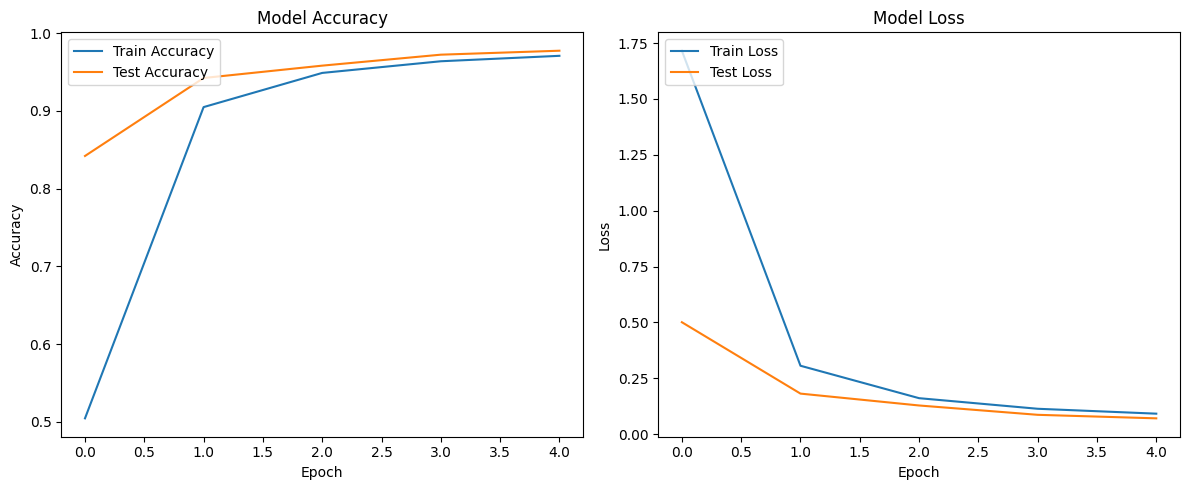

Model: "res_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 7, 7, 64)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block (ResnetBlock)      │ ?                      │       148,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_1 (ResnetBlock)    │ ?                      │       526,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_2 (ResnetBlock)    │ ?                      │     2,102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_3 (ResnetBlock)    │ ?                      │     8,399,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,186,188 (42.67 MB)

 Trainable params: 11,178,378 (42.64 MB)

 Non-trainable params: 7,808 (30.50 KB)

 Optimizer params: 2 (12.00 B)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9774 - loss: 0.0711
Accuracy on test set: 0.98


In [5]:
net = ResNet()
net.build((1, 28, 28, 1))
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
net.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])


history = net.fit(mnist_train, epochs=5, validation_data=mnist_test) # Train for 10 epochs and record validation metrics

# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy') # Plot validation accuracy
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss') # Plot validation loss
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

net.summary()
print("Accuracy on test set: {:.2f}".format(net.evaluate(mnist_test)[1]))

# Uncertainty in DL - MC Dropout


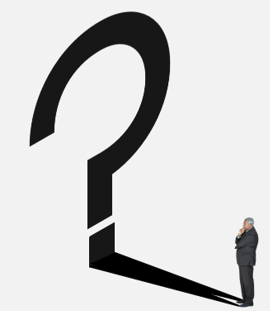

## **Assignment #2**: Code a MC Dropout-based version of ResNet18

In [6]:
class ResNetMC(tf.keras.Model):

    def __init__(self, num_classes=10, mc_dropout=None):
        super(ResNetMC, self).__init__()
        self.mc_dropout = mc_dropout

        # Ensure dropout_rate is a float, default to 0.0 if mc_dropout is None
        dropout_rate_for_layers = mc_dropout if mc_dropout is not None else 0.0

        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

        # Create dropout layers with the resolved dropout_rate
        self.drop1 = tf.keras.layers.Dropout(dropout_rate_for_layers)
        self.drop2 = tf.keras.layers.Dropout(dropout_rate_for_layers)
        self.drop3 = tf.keras.layers.Dropout(dropout_rate_for_layers)
        self.drop4 = tf.keras.layers.Dropout(dropout_rate_for_layers)
        self.drop5 = tf.keras.layers.Dropout(dropout_rate_for_layers)

    def call(self, inputs):
        x = self.block_a(inputs)
        if self.mc_dropout:
            x = self.drop1(x, training=True)
        x = self.block_b(x)
        if self.mc_dropout:
            x = self.drop2(x, training=True)
        x = self.block_c(x)
        if self.mc_dropout:
            x = self.drop3(x, training=True)
        x = self.block_d(x)
        if self.mc_dropout:
            x = self.drop4(x, training=True)
        x = self.block_e(x)
        if self.mc_dropout:
            x = self.drop5(x, training=True)
        x = self.global_pool(x)
        return self.classifier(x)

## Load EMNIST

In [7]:
def show_images_from_npy(array, cmap=None):
    fig, ax = plt.subplots(1, 5)
    ax = ax.ravel()
    j = 0
    for idx in np.random.randint(0, array.shape[0], 5):
        ax[j].imshow(array[idx], cmap=cmap)
        ax[j].axis('off')
        j += 1


In [8]:
emnist = np.load('/content/emnist_images.npy')
emnist_numpy = (emnist / 255).astype(np.float32)

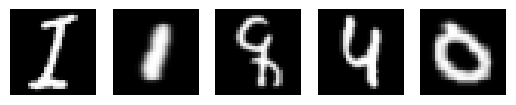

In [9]:
show_images_from_npy(emnist_numpy, cmap="gray")

N.B. Do not shuffle emnist

## **Assignment #3**: Code a wrapper for a MC-based network
Implements:
1.   Several metrics to compute uncertainty
2.   Method to reierate predictions


In [12]:
class UncertaintyWrapper(tf.keras.Model):

    def __init__(self, num_classes=10, mc_dropout=None):
        super(UncertaintyWrapper, self).__init__()
        print(f"MC Dropout is set to {mc_dropout}")
        self.model = ResNetMC(num_classes=num_classes, mc_dropout=mc_dropout)
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def build(self, input_shape):
        # Explicitly build the internal model with the given input shape
        self.model.build(input_shape)
        # Mark the UncertaintyWrapper itself as built
        super().build(input_shape)

    def call(self, inputs):
        return self.model(inputs)

    def uncertainty_metrics(self, multiple_preds):
        return {metric: self._compute_uncertainty(
            metric,
            multiple_preds) for metric in self._uncertainty_metrics.keys()}

    def _normalize(self, values):
            denom = values.max() - values.min()
            if denom == 0:
                return np.zeros_like(values, dtype=np.float32)
            return (values - values.min()) / denom

    def _compute_uncertainty(self, metric, multiple_preds):
        try:
            print("Done {}".format(metric))
            return self._normalize(
                self._uncertainty_metrics[metric](multiple_preds))
        except KeyError:
            print("{} not implemented.".format(metric))

    def predict_many_times(self, inputs, draws=2):
        multiple_preds = list()
        for _ in range(draws):
            multiple_preds.append(self.predict(inputs))
            print("Prediction {} done".format(_))
        return np.array(multiple_preds)

    def _average_prediction(self, multiple_preds):
        return np.mean(multiple_preds, axis=0)


    def _entropy(self, multiple_preds):
        avg_preds = self._average_prediction(multiple_preds)
        eps = 1e-5
        entropy = -1 * np.sum(avg_preds * np.log(avg_preds + eps), axis=1)
        return entropy

    def _variance(self, multiple_preds):
        # variance across draws (axis=0), averaged over classes (axis=1)
        # multiple_preds shape: (draws, n_samples, n_classes)
        variance = np.mean(np.var(multiple_preds, axis=0), axis=1)
        return variance

    def _max_softmax_response(self, multiple_preds):
        avg_preds = self._average_prediction(multiple_preds)
        max_response = np.max(avg_preds, axis=1)
        return 1-max_response

MC Dropout is set to 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_mc_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "uncertainty_wrapper_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ res_net_mc_1 (ResNetMC)         │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.9049 - loss: 0.3011 - val_accuracy: 0.9655 - val_loss: 0.1087
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9722 - loss: 0.0916 - val_accuracy: 0.9795 - val_loss: 0.0677
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9779 - loss: 0.0706 - val_accuracy: 0.9826 - val_loss: 0.0515
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9833 - loss: 0.0535 - val_accuracy: 0.9863 - val_loss: 0.0478
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9853 - loss: 0.0471 - val_accuracy: 0.9864 - val_loss: 0.0419


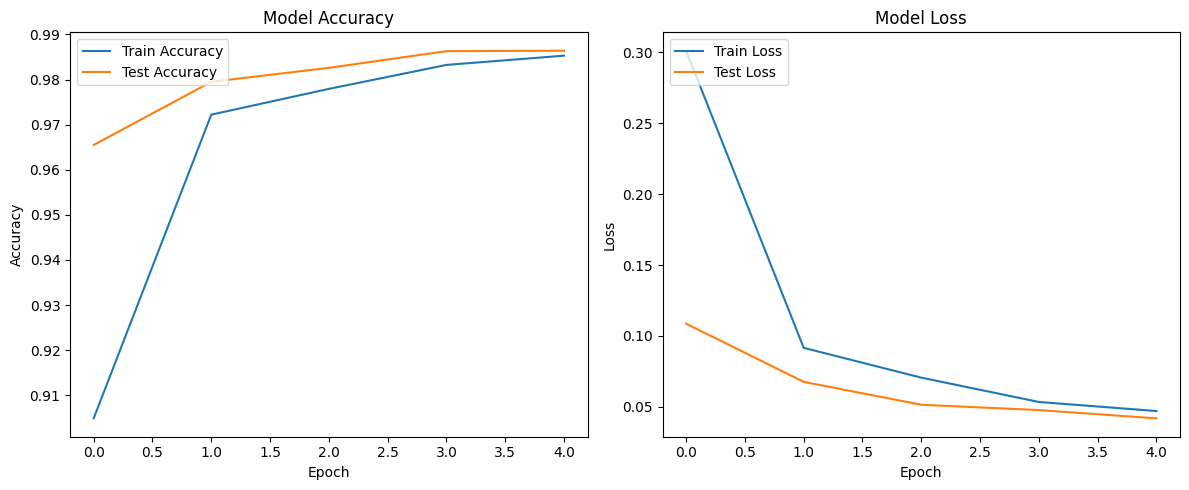

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9851 - loss: 0.0480
Accuracy on test set: 0.99


In [13]:
net_unc = UncertaintyWrapper(mc_dropout=0.1)
net_unc.build((1, 28, 28, 1))
net_unc.summary()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
net_unc.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

history = net_unc.fit(mnist_train, epochs=5, validation_data=mnist_test) # Train for 5 epochs and record validation metrics

# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy') # Plot validation accuracy
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss') # Plot validation loss
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("Accuracy on test set: {:.2f}".format(net_unc.evaluate(mnist_test)[1]))

## Compute MC predicitons and compare with *deterministic* uncertainty computation

In [14]:
multiple_preds_emnist = net_unc.predict_many_times(emnist, draws=10)
multiple_preds_mnist = net_unc.predict_many_times(mnist_test, draws=10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step
Prediction 0 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction 1 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction 2 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 3 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 4 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 5 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 6 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 7 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 8 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction 9 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step
Prediction 0 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Prediction 1 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Prediction 2 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Prediction 3 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Prediction 4 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Prediction 5 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Prediction 6 done
79/79 ━

In [15]:
# Generate single deterministic predictions
det_preds_mnist = net_unc.predict(mnist_test)   # (n_samples, n_classes)
det_preds_emnist = net_unc.predict(emnist)      # (n_samples, n_classes)

def compute_deterministic_uncertainty(preds):
    eps = 1e-5
    entropy = -np.sum(preds * np.log(preds + eps), axis=1)
    variance = np.var(preds, axis=1)  # variance across classes (not draws)
    max_sr = 1.0 - np.max(preds, axis=1)

    def norm(v):
        d = v.max() - v.min()
        return (v - v.min()) / d if d > 0 else np.zeros_like(v, dtype=np.float32)

    return {
        'entropy': norm(entropy),
        'variance': norm(variance),
        'max_softmax_response': norm(max_sr),
    }

uncertainties = dict()
uncertainties_deterministic = dict()
uncertainties['mnist'] = net_unc.uncertainty_metrics(multiple_preds_mnist)
uncertainties['emnist'] = net_unc.uncertainty_metrics(multiple_preds_emnist)
uncertainties_deterministic['mnist'] = compute_deterministic_uncertainty(det_preds_mnist)
uncertainties_deterministic['emnist'] = compute_deterministic_uncertainty(det_preds_emnist)


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


## **Assignment #4** Uncertainty metrics distributions for MNIST and EMNIST
Plot distributions in form of histograms


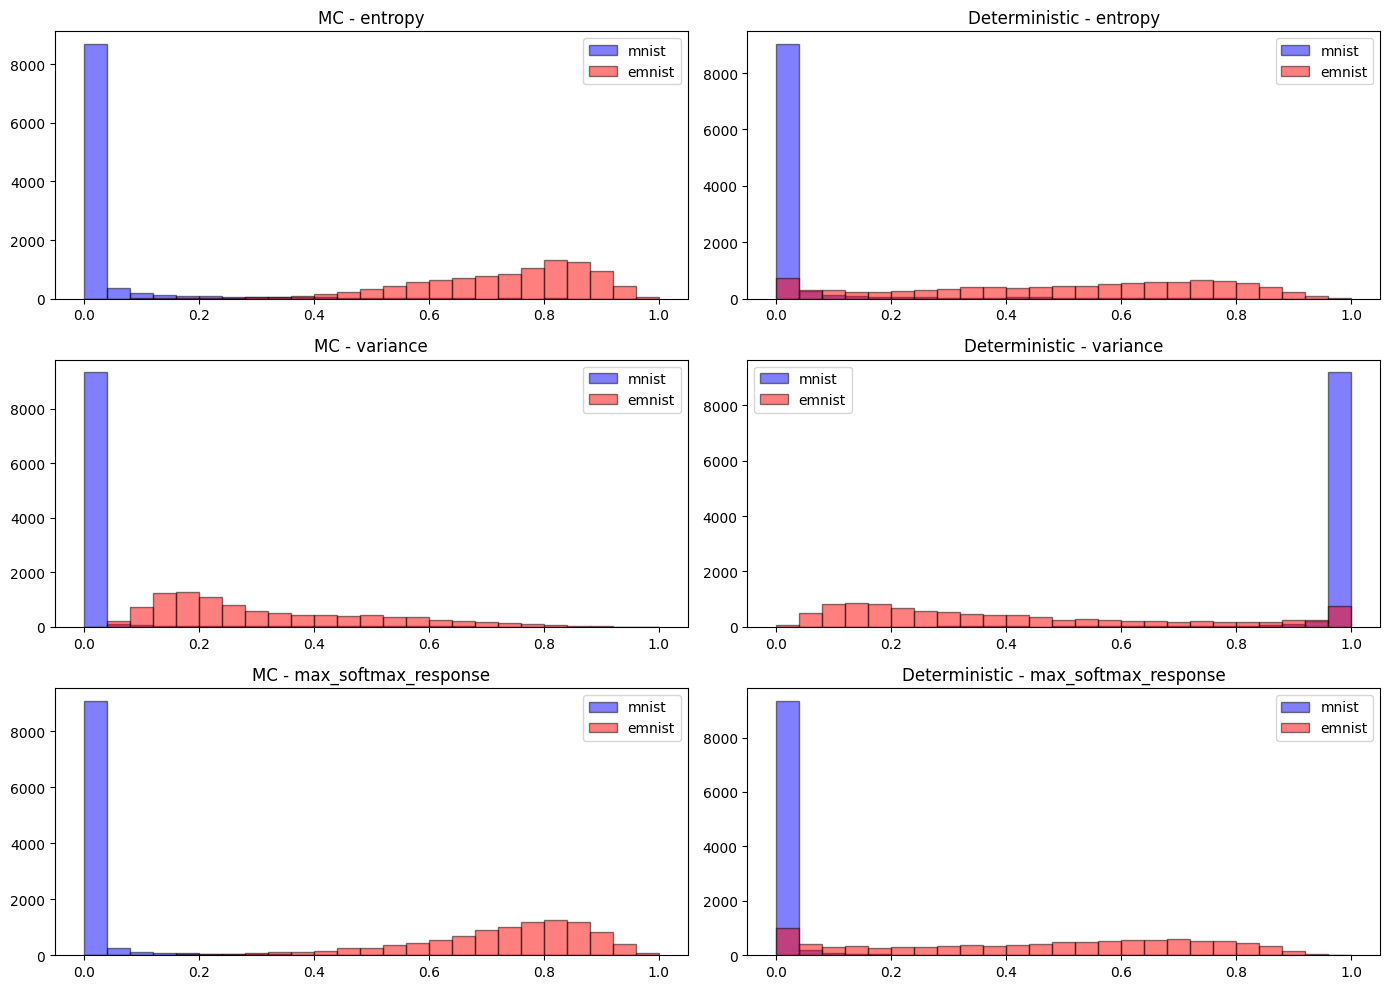

In [16]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 2, figsize=(14, 10))
for i, measure in enumerate(net_unc._uncertainty_metrics.keys()):
    # MC Dropout
    axes[i, 0].set_title(f"MC - {measure}")
    axes[i, 0].hist(uncertainties['mnist'][measure], color="blue", bins=25, edgecolor='black', alpha=0.5, label="mnist")
    axes[i, 0].hist(uncertainties['emnist'][measure], color="red", bins=25, edgecolor='black', alpha=0.5, label="emnist")
    axes[i, 0].legend()

    # Deterministic
    axes[i, 1].set_title(f"Deterministic - {measure}")
    axes[i, 1].hist(uncertainties_deterministic['mnist'][measure], color="blue", bins=25, edgecolor='black', alpha=0.5, label="mnist")
    axes[i, 1].hist(uncertainties_deterministic['emnist'][measure], color="red", bins=25, edgecolor='black', alpha=0.5, label="emnist")
    axes[i, 1].legend()
plt.tight_layout()
plt.show()

## **Assignment #5** Take a look at confident and not-confident predictions for EMNIST
Filter confident and not-confident images based on uncertainty values and plot some of them

Most Confident EMNIST Predictions:


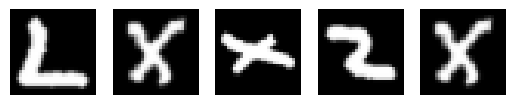

Most Unconfident EMNIST Predictions:


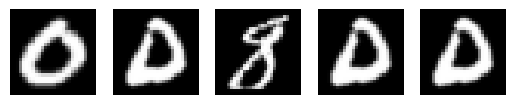

In [17]:
emnist_entropy = uncertainties['emnist']['entropy']
# Get indices sorted by entropy
sorted_indices = np.argsort(emnist_entropy)
confident_idx = sorted_indices[:5]  # lowest entropy
unconfident_idx = sorted_indices[-5:] # highest entropy
print("Most Confident EMNIST Predictions:")
show_images_from_npy(emnist_numpy[confident_idx], cmap="gray")
plt.show()
print("Most Unconfident EMNIST Predictions:")
show_images_from_npy(emnist_numpy[unconfident_idx], cmap="gray")
plt.show()

# **Assignment #6** Uncertainty in DL - Ensamble
Populate a list of ResNet18 classifiers to create a group of expert (ignore indipendancy among datasets, i.e. different training cohorts).

In [18]:
nets = list()
for _ in range(3):
    net = ResNet()
    net.build((1, 28, 28, 1))
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    net.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    net.fit(mnist_train, epochs=5)
    nets.append(net)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.4891 - loss: 1.7357
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9054 - loss: 0.3017
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9517 - loss: 0.1507
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9656 - loss: 0.1094
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9721 - loss: 0.0897
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.5281 - loss: 1.5751
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9030 - loss: 0.3062
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9503 - loss: 0.1581
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9643 - loss: 0.1114
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9719 - loss: 0.0894
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.5665 - loss: 1.5625
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9170 - loss: 0.2662
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9552 - loss: 0.1456
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9669 - loss: 0.1069
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9715 - loss: 0.0888


In [19]:
emnist_preds_ensamble = list()
mnist_preds_ensamble = list()
for net in nets:
    emnist_preds_ensamble.append(net.predict(emnist))
    mnist_preds_ensamble.append(net.predict(mnist_test))

uncertainties_ensable = dict()
uncertainties_ensable['mnist'] = net_unc.uncertainty_metrics(np.array(mnist_preds_ensamble))
uncertainties_ensable['emnist'] = net_unc.uncertainty_metrics(np.array(emnist_preds_ensamble))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


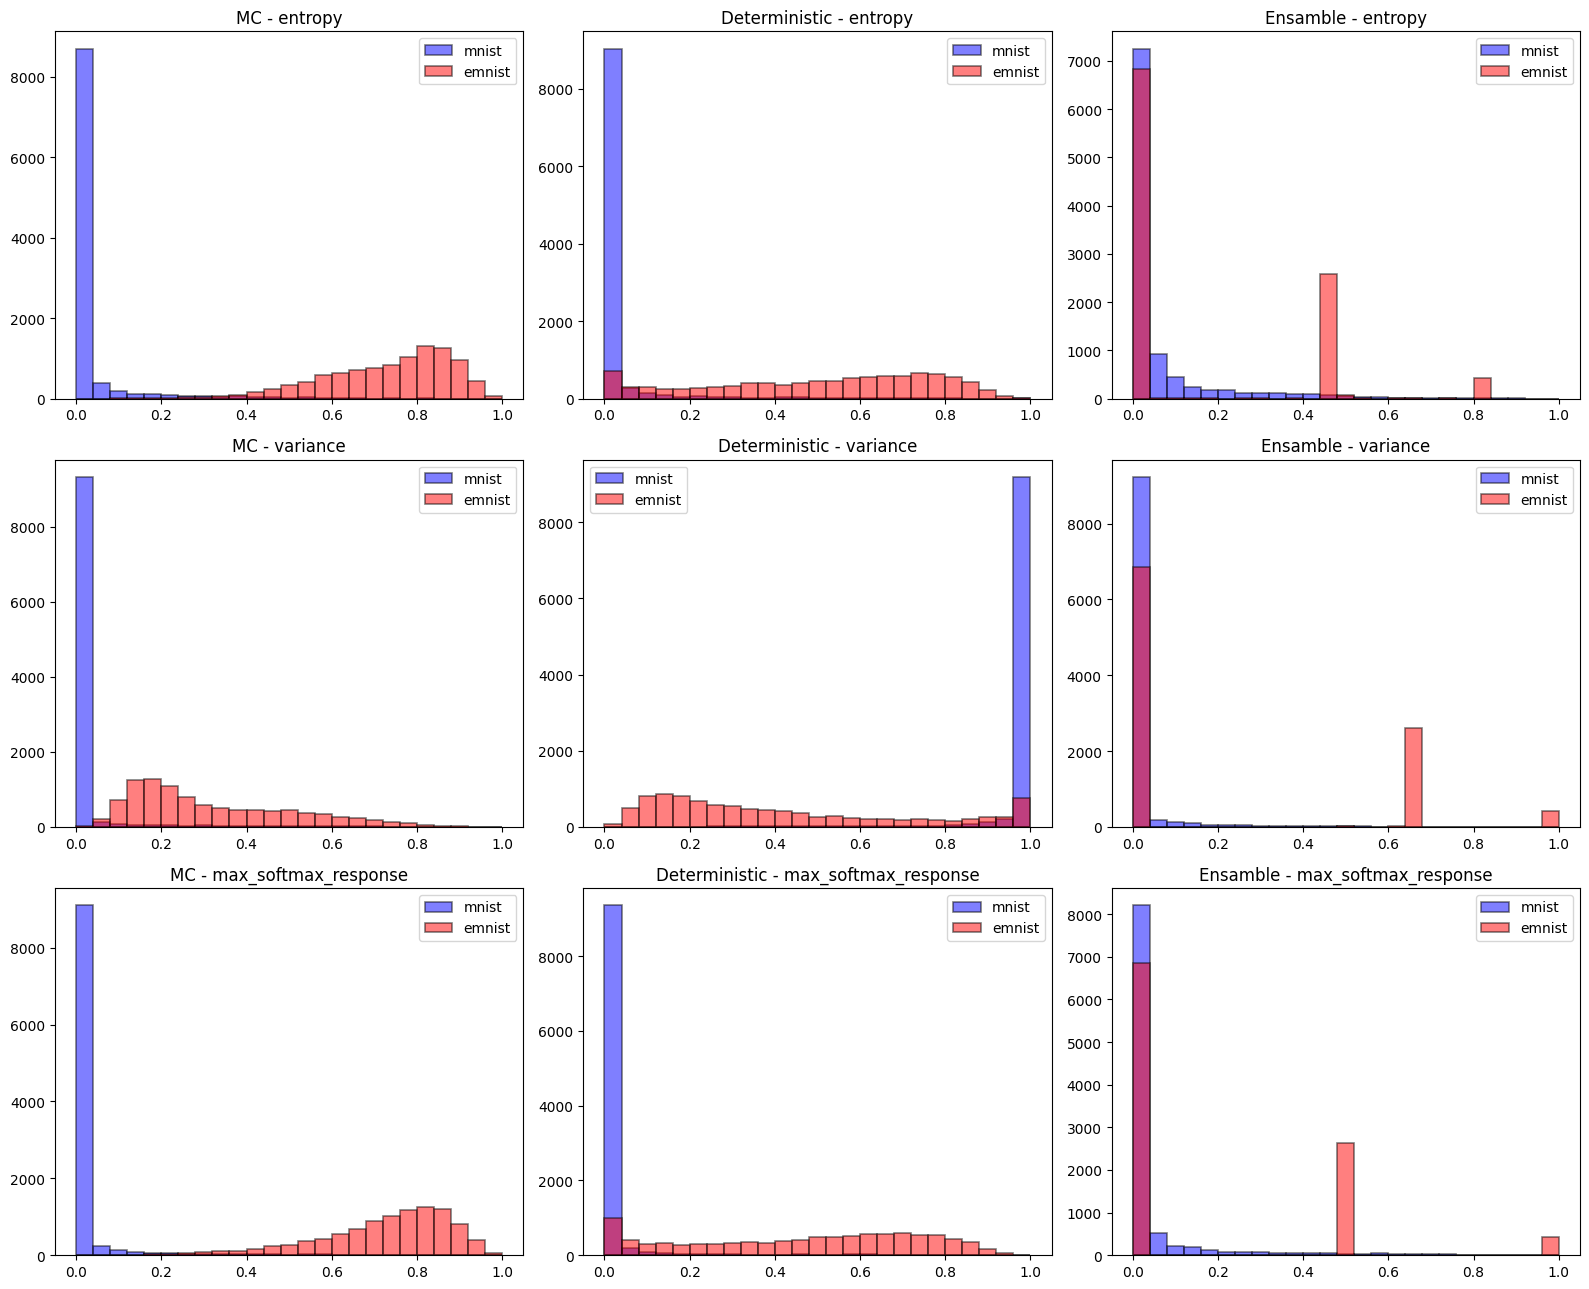

In [20]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 3, figsize=(16, 13))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0].set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1].set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2].set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
plt.tight_layout()

In [21]:
import tensorflow_probability as tfp
#
tfd = tfp.distributions
NUM_TRAIN_EXAMPLES = 50000
NUM_CLASSES = 10
LR = 0.01

# Uncertainty in DL - Variational Inference

In [22]:
class ResidualVI(tf.keras.Model):
    """The Residual block of ResNet."""

    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /
                                       tf.cast(NUM_TRAIN_EXAMPLES, dtype=tf.float32))
        self.conv1 = tfp.layers.Convolution2DFlipout(
            num_channels,
            kernel_size=3,
            padding='same',
            strides=strides,
            kernel_divergence_fn=self.kl_divergence_function,
            activation=tf.nn.relu)
        self.conv2 = tfp.layers.Convolution2DFlipout(
            num_channels,
            kernel_size=3,
            padding='same',
            kernel_divergence_fn=self.kl_divergence_function,
            activation=tf.nn.relu)
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)

            self.conv_1x1 = tfp.layers.Convolution2DFlipout(
                num_channels,
                kernel_size=1,
                strides=strides,
                kernel_divergence_fn=self.kl_divergence_function)

        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

class ResnetBlockVI(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True,
                 **kwargs):
        super(ResnetBlockVI, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    ResidualVI(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(ResidualVI(num_channels))

    def call(self, X):
        for layer in self.residual_layers:
            X = layer(X)
        return X

class ResNetVI(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNetVI, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlockVI(64, 2, downscale=False)
        self.block_c = ResnetBlockVI(128, 2)
        self.block_d = ResnetBlockVI(256, 2)
        self.block_e = ResnetBlockVI(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

In [23]:
# VIWrapper is defined in the next cell


In [24]:
class VIWrapper(UncertaintyWrapper):
    def __init__(self, num_classes=10):
        super().__init__(num_classes=num_classes, mc_dropout=0.0)

        # variational version
        self.model = ResNetVI(num_classes=num_classes)


In [25]:
net_vi = VIWrapper()
net_vi.build((1, 28, 28, 1)) # Explicitly build the model with the expected input shape
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
# ...
net_vi.compile(optimizer, loss='categorical_crossentropy',
               metrics=['accuracy'])

net_vi.fit(mnist_train, epochs=5)

print("Accuracy on test set: {:.2f}".format(net_vi.evaluate(mnist_test)[1]))
preds_mnist = net_vi.predict(mnist_test)

MC Dropout is set to 0.0
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_vi', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow_probability/python/layers/util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.12/dist-packages/tensorflow_probability/python/layers/util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(
/usr/local/lib/python3.12/dist-packages/tf_keras/src

469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 94ms/step - accuracy: 0.1029 - loss: 532.8030
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1075 - loss: 2.3347
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1087 - loss: 2.3065
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1105 - loss: 2.3051
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1103 - loss: 2.3080
79/79 ━━━━━━━━━━━━━━━━━━━━ 68s 430ms/step - accuracy: 0.1075 - loss: 2.3023
Accuracy on test set: 0.11
79/79 ━━━━━━━━━━━━━━━━━━━━ 70s 458ms/step


In [26]:
vi_preds_emnist = net_vi.predict_many_times(emnist, draws=10)
vi_preds_mnist = net_vi.predict_many_times(mnist_test, draws=10)
uncertainties_vi = dict()
uncertainties_vi['mnist'] = net_unc.uncertainty_metrics(np.array(vi_preds_mnist))
uncertainties_vi['emnist'] = net_unc.uncertainty_metrics(np.array(vi_preds_emnist))

313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 124ms/step
Prediction 0 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction 1 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Prediction 2 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction 3 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction 4 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction 5 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Prediction 6 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Prediction 7 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction 8 done
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction 9 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Prediction 0 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Prediction 1 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Prediction 2 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Prediction 3 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Prediction 4 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Prediction 5 done
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Prediction 6 done
79/79 

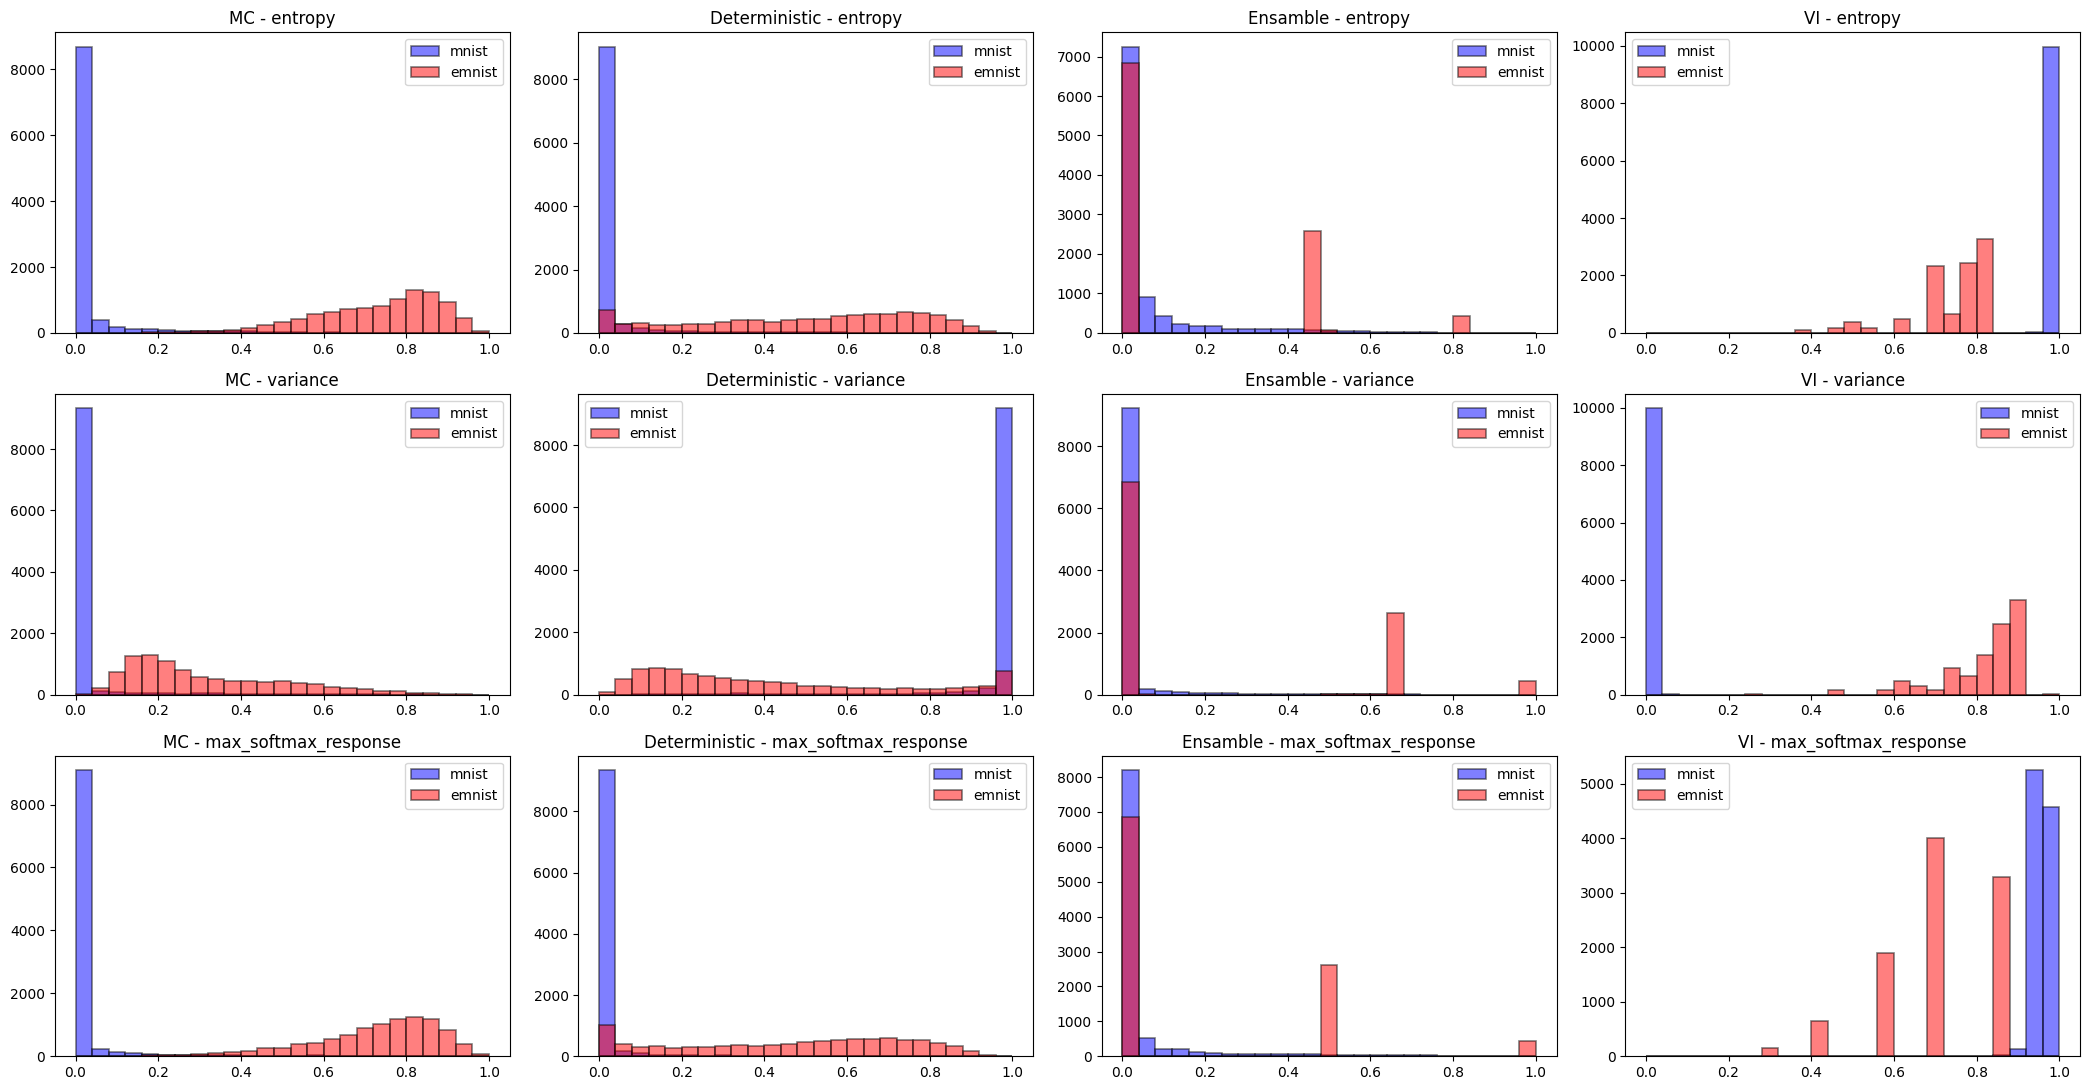

In [27]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 4, figsize=(21, 11))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0] .set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1] .set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2] .set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
    ax[3] .set_title(f"VI - {measure}")
    ax[3].hist(uncertainties_vi['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[3].hist(uncertainties_vi['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[3].legend()
plt.tight_layout()

# **Assignment #7** Uncertainty in DL - Test Time Augmentation-Based
See [data augmentation for tensorflow and keras](https://www.tensorflow.org/tutorials/images/data_augmentation) to implement some data augmentation techniques.

In [28]:
class TTAWrapper(UncertaintyWrapper):
    def __init__(self, num_classes=10):
        super(TTAWrapper, self).__init__()
        self.model = ResNet()
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def call(self, inputs):
        return self.model(inputs)

    def predict_many_times(self, ds_input, policy, repeat=1):
        pred_augmented = list()

        policy_identity = [tf.keras.Sequential([
            tf.keras.layers.Layer()])]

        policy_random_crop = [tf.keras.Sequential([
            tf.keras.layers.ZeroPadding2D(padding=2), # Pad to maintain dimensions
            tf.keras.layers.RandomCrop(28, 28)
        ])]

        policy_random_flip = [tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal_and_vertical")
        ])]

        policy_random_contrast = [tf.keras.Sequential([
            tf.keras.layers.RandomContrast(0.2)
        ])]

        policy_random_zoom = [tf.keras.Sequential([
            tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2)
        ])]

        policies = dict()
        policies['identity'] = policy_identity
        policies['random_crop'] = policy_random_crop
        policies['random_contrast'] = policy_random_contrast
        policies['random_zoom'] = policy_random_zoom
        policies['random_flip'] = policy_random_flip

        # Extend policies for repeat
        policies['random_crop'] = sum([policies['random_crop'] for _ in range(repeat)], [])
        policies['random_contrast'] = sum([policies['random_contrast'] for _ in range(repeat)], [])
        policies['random_zoom'] = sum([policies['random_zoom'] for _ in range(repeat)], [])
        policies['random_flip'] = sum([policies['random_flip'] for _ in range(repeat)], [])

        is_numpy_input = isinstance(ds_input, np.ndarray)

        if is_numpy_input:
            # For numpy arrays (like emnist), assume it's just images.
            # Convert to TF Dataset, expand dims for channels (if needed), and batch.
            # emnist_numpy is (num_images, 28, 28), so expand_dims for channel dimension
            ds_to_process = tf.data.Dataset.from_tensor_slices(tf.expand_dims(ds_input, axis=-1)).batch(128).prefetch(tf.data.AUTOTUNE)
        else:
            # For tf.data.Dataset (like mnist_test), use it directly. Assume it's already batched if desired.
            ds_to_process = ds_input

        for p in policies[policy]:
            if is_numpy_input:
                # Apply augmentation to images only
                ds_augmented = ds_to_process.map(lambda x: p(x, training=True), num_parallel_calls=tf.data.AUTOTUNE)
            else:
                # Apply augmentation to images, keep labels (assuming ds_input yields (image, label))
                ds_augmented = ds_to_process.map(lambda x, y: (p(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

            pred_augmented.append(self.predict(ds_augmented))

        return np.array(pred_augmented)

In [29]:
net_tta = TTAWrapper()
net_tta.build((1, 28, 28, 1))
net_tta.summary()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
net_tta.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
net_tta.fit(mnist_train, epochs=5)
print("Accuracy on test set: {:.2f}".format(net_tta.evaluate(mnist_test)[1]))

MC Dropout is set to None


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "tta_wrapper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ res_net_mc_3 (ResNetMC)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_4 (ResNet)              │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5548 - loss: 1.6174
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9135 - loss: 0.2744
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9562 - loss: 0.1407
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9667 - loss: 0.1063
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9724 - loss: 0.0874
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9777 - loss: 0.0706
Accuracy on test set: 0.98


In [30]:
emnist_preds_tta = net_tta.predict_many_times(emnist, "random_zoom", repeat=10)
mnist_preds_tta = net_tta.predict_many_times(mnist_test, "random_zoom", repeat=10)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


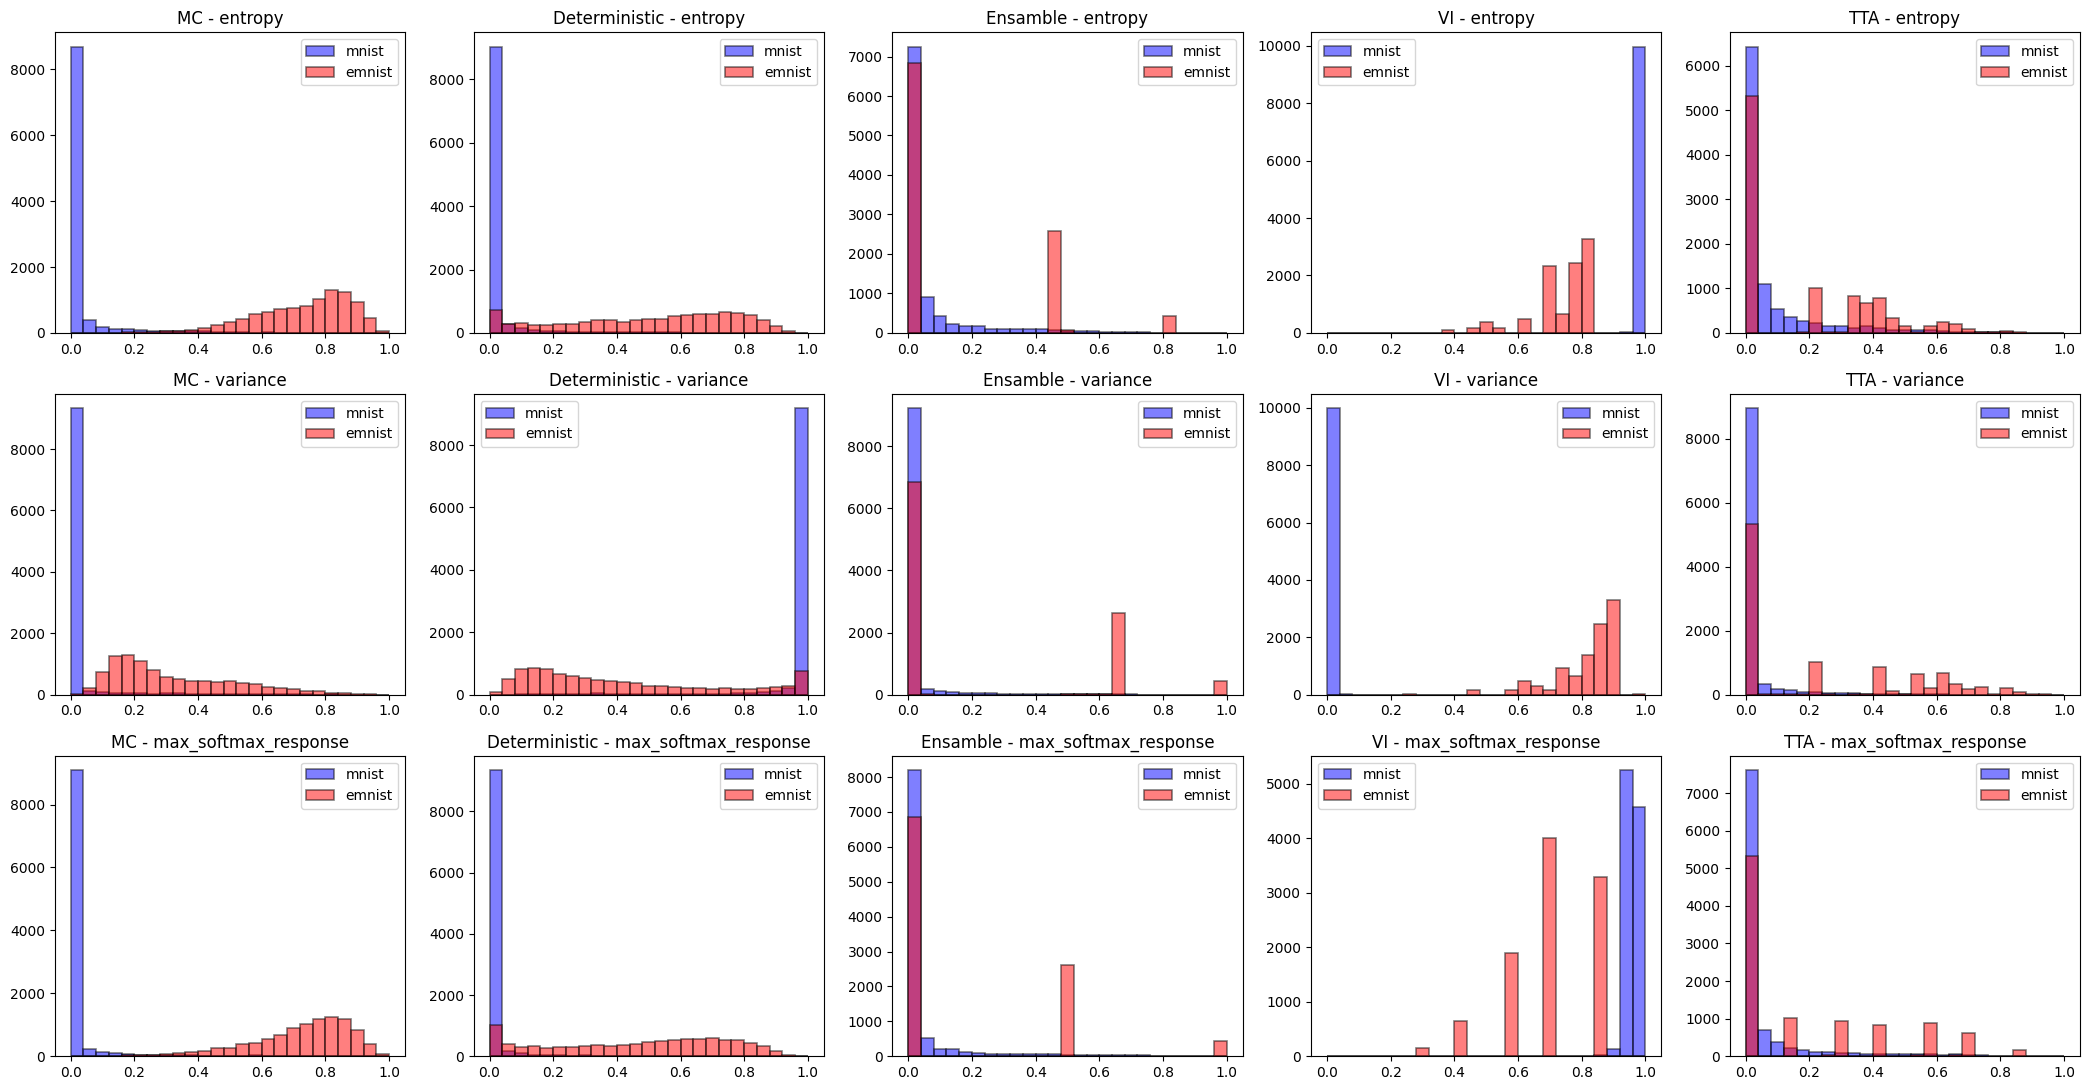

In [31]:
uncertainties_tta = dict()
uncertainties_tta['mnist'] = net_tta.uncertainty_metrics(np.array(mnist_preds_tta))
uncertainties_tta['emnist'] = net_tta.uncertainty_metrics(np.array(emnist_preds_tta))
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 5, figsize=(21, 11))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0].set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1].set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2].set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
    ax[3].set_title(f"VI - {measure}")
    ax[3].hist(uncertainties_vi['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[3].hist(uncertainties_vi['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[3].legend()
    ax[4].set_title(f"TTA - {measure}")
    ax[4].hist(uncertainties_tta['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[4].hist(uncertainties_tta['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[4].legend()
plt.tight_layout()